# Camada Gold — Análise e Visualização

Explora os 3 datasets analíticos da Gold: indicador por município,
comparação metas x resultados por UF e evolução temporal (Brasil + UF).
Fecha com uma seção sobre como a Gold alimenta aplicações de IA, conforme
pedido no Tech Challenge.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq

sys.path.insert(0, str(Path.cwd().parent))
from pipeline.batch.config import GOLD_DIR

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 100

def ler_gold(nome):
    return pq.ParquetDataset(str(GOLD_DIR / nome)).read().to_pandas()

municipios = ler_gold("indicador_alfabetizacao_municipio")
metas_uf = ler_gold("comparacao_metas_resultados")
evolucao = ler_gold("evolucao_temporal")

print(f"indicador_alfabetizacao_municipio: {len(municipios):,} linhas")
print(f"comparacao_metas_resultados: {len(metas_uf):,} linhas")
print(f"evolucao_temporal: {len(evolucao):,} linhas")

indicador_alfabetizacao_municipio: 11,030 linhas
comparacao_metas_resultados: 24 linhas
evolucao_temporal: 52 linhas


## 1. Evolução temporal do indicador nacional

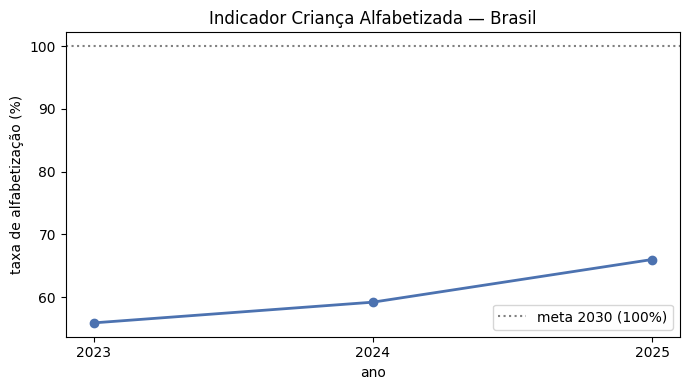

,ano,indicador,variacao_yoy
0,2023,55.9,NaN
1,2024,59.2,3.3
2,2025,66.0,6.8


In [2]:
brasil = evolucao[evolucao["nivel"] == "brasil"].sort_values("ano")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(brasil["ano"], brasil["indicador"], marker="o", color="#4C72B0", linewidth=2)
ax.set_title("Indicador Criança Alfabetizada — Brasil")
ax.set_xlabel("ano")
ax.set_ylabel("taxa de alfabetização (%)")
ax.set_xticks(brasil["ano"])
ax.axhline(100, color="grey", linestyle=":", label="meta 2030 (100%)")
ax.legend()
plt.tight_layout()
plt.show()

brasil[["ano", "indicador", "variacao_yoy"]]

## 2. Evolução por UF — as 6 maiores altas e as 6 maiores quedas (2023→2024)

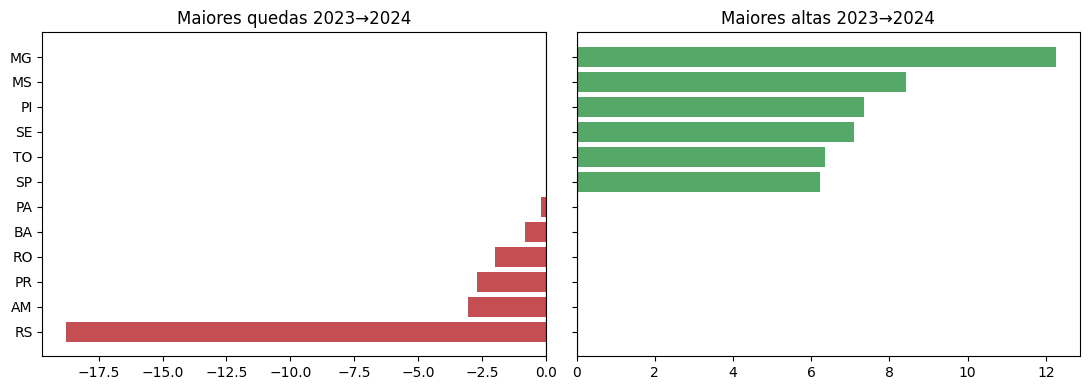

In [3]:
uf = evolucao[evolucao["nivel"] == "uf"].copy()
variacao_2024 = uf[uf["ano"] == 2024][["referencia", "variacao_yoy"]].dropna().sort_values("variacao_yoy")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
piores = variacao_2024.head(6)
melhores = variacao_2024.tail(6)

axes[0].barh(piores["referencia"], piores["variacao_yoy"], color="#C44E52")
axes[0].set_title("Maiores quedas 2023→2024")
axes[1].barh(melhores["referencia"], melhores["variacao_yoy"], color="#55A868")
axes[1].set_title("Maiores altas 2023→2024")
for a in axes:
    a.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 3. Metas x resultados por UF (2024, escopo Pública)

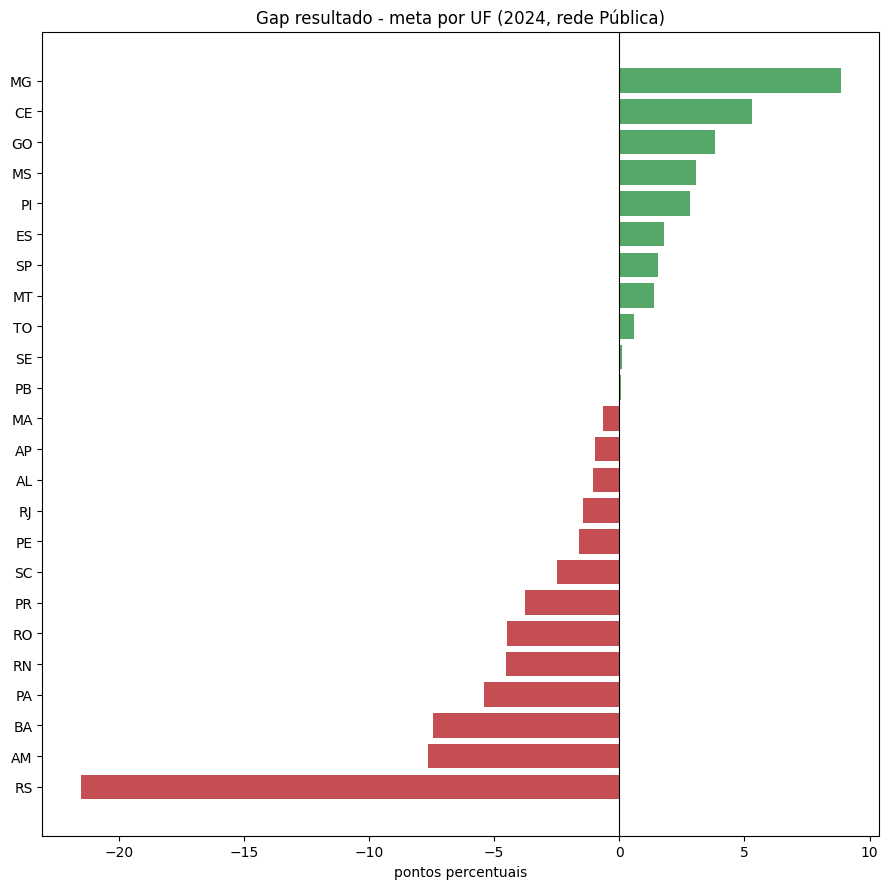

UFs que bateram a meta estadual em 2024: 11/24


In [4]:
m24 = metas_uf[metas_uf["ano"] == 2024].sort_values("gap")

fig, ax = plt.subplots(figsize=(9, 9))
cores = ["#C44E52" if g < 0 else "#55A868" for g in m24["gap"]]
ax.barh(m24["sigla_uf"], m24["gap"], color=cores)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Gap resultado - meta por UF (2024, rede Pública)")
ax.set_xlabel("pontos percentuais")
plt.tight_layout()
plt.show()

print(f"UFs que bateram a meta estadual em 2024: {(m24['atingiu_meta']).sum()}/{len(m24)}")

## 4. Distribuição de risco entre municípios

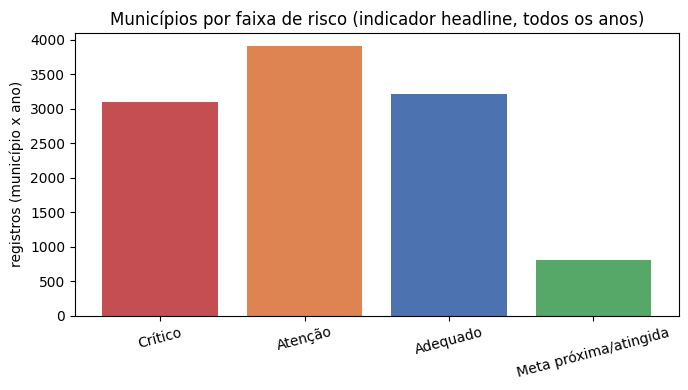

faixa_risco
Crítico                  3097
Atenção                  3907
Adequado                 3221
Meta próxima/atingida     805
Name: count, dtype: int64

In [5]:
ordem = ["Crítico", "Atenção", "Adequado", "Meta próxima/atingida"]
cores_risco = {"Crítico": "#C44E52", "Atenção": "#DD8452", "Adequado": "#4C72B0", "Meta próxima/atingida": "#55A868"}
contagem = municipios["faixa_risco"].value_counts().reindex(ordem)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(contagem.index, contagem.values, color=[cores_risco[c] for c in contagem.index])
ax.set_title("Municípios por faixa de risco (indicador headline, todos os anos)")
ax.set_ylabel("registros (município x ano)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

contagem

## 5. Municípios mais distantes da meta municipal (2024)

In [6]:
piores_municipios = municipios[
    (municipios["ano"] == 2024) & municipios["gap_meta_municipal"].notna()
].sort_values("gap_meta_municipal").head(10)

piores_municipios[["nome_municipio", "sigla_uf", "taxa_alfabetizacao_municipal",
                    "meta_alfabetizacao_municipal", "gap_meta_municipal"]]

,nome_municipio,sigla_uf,taxa_alfabetizacao_municipal,meta_alfabetizacao_municipal,gap_meta_municipal
10855,Sério,RS,11.10,80.00,-68.90
10803,Arroio do Padre,RS,18.20,80.00,-61.80
10672,Jaboticaba,RS,25.00,80.00,-55.00
7804,São Vendelino,RS,25.00,80.00,-55.00
9821,São Nicolau,RS,7.10,61.56,-54.46
7709,Dona Francisca,RS,26.70,80.00,-53.30
8668,Bozano,RS,27.30,80.00,-52.70
8931,Nova Ramada,RS,28.00,80.00,-52.00
8673,Monte do Carmo,TO,19.71,71.56,-51.85
10866,Sentinela do Sul,RS,23.50,74.77,-51.27


## 6. Aplicação em IA

A camada Gold já está no formato tabular (uma linha por município/ano, chaves
limpas, sem valores fora de domínio) necessário para alimentar:

- **Modelos preditivos de alfabetização por município** — `indicador_alfabetizacao_municipio`
  como base, usando `taxa_alfabetizacao` de anos anteriores, `gap_indicador_nacional`
  e (via join adicional com a Silver) as `proporcao_aluno_nivel_*` como features para
  prever se um município vai atingir a meta do ano seguinte.
- **Clusters de vulnerabilidade educacional** — `faixa_risco` já é uma
  categorização inicial; um clustering (k-means/hierárquico) sobre
  `taxa_alfabetizacao`, `gap_meta_municipal` e `gap_indicador_nacional`
  refinaria essa segmentação para priorização de política pública.
- **Análise de desigualdade educacional** — `comparacao_metas_resultados`
  por UF, cruzado com `nome_regiao` da camada Silver, evidencia disparidades
  regionais sem precisar reprocessar dados brutos.

Abaixo, uma checagem simples de correlação entre o indicador e o gap em
relação à meta nacional — sinal de que features desse tipo carregam
informação útil para um modelo preditivo:

In [7]:
cor = municipios[["taxa_alfabetizacao", "gap_indicador_nacional", "gap_meta_municipal"]].corr()
cor

,taxa_alfabetizacao,gap_indicador_nacional,gap_meta_municipal
taxa_alfabetizacao,1.000000,0.996345,0.620312
gap_indicador_nacional,0.996345,1.000000,0.620312
gap_meta_municipal,0.620312,0.620312,1.000000


## Conclusões

- O indicador nacional subiu de 55,9% (2023) para 66,0% (2025) — ainda distante
  da meta de 100% até 2030, mas em trajetória de alta.
- Há grande heterogeneidade entre UFs: algumas já superam sua meta estadual,
  outras estão vários pontos percentuais abaixo.
- A faixa "Crítico" concentra uma parcela relevante dos registros município-ano,
  reforçando a necessidade de priorização territorial de política pública.
- A Gold está pronta para consumo por dashboards, análises estatísticas e como
  base de features para modelos preditivos/clustering, sem necessidade de
  reprocessar a Bronze/Silver.